In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("student_habits_performance.csv")

In [4]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [6]:
df.shape

(1000, 16)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sns.set(style="whitegrid")

In [9]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [14]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1000,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [19]:
df.select_dtypes(include='object').columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [20]:
categorical_cols = ['gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation']

In [22]:
for col in categorical_cols:
    print(f'value_counts for {col} : \n {df[col].value_counts()}')

value_counts for gender : 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
value_counts for part_time_job : 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
value_counts for diet_quality : 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
value_counts for parental_education_level : 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
value_counts for internet_quality : 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
value_counts for extracurricular_participation : 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


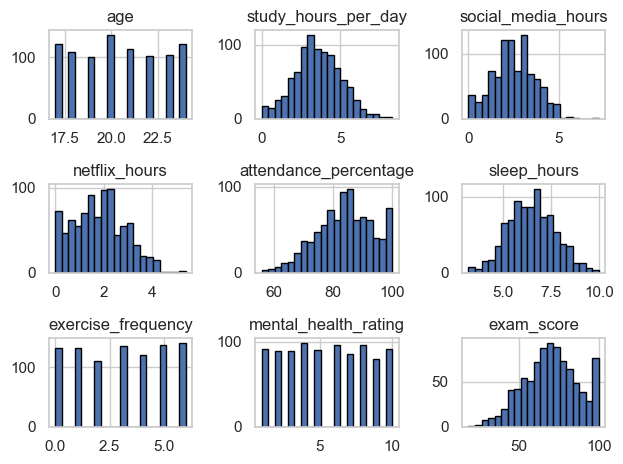

In [23]:
df.hist(bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

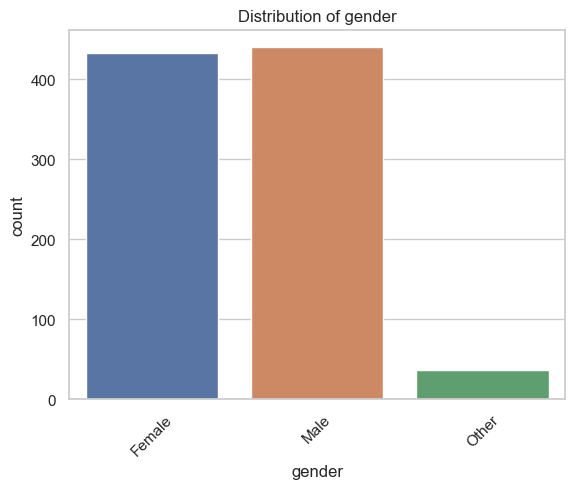

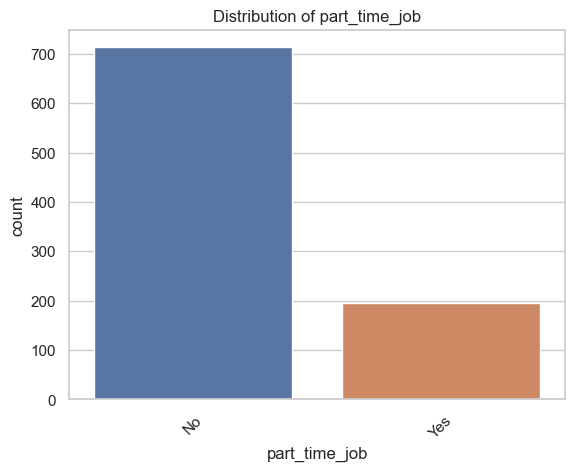

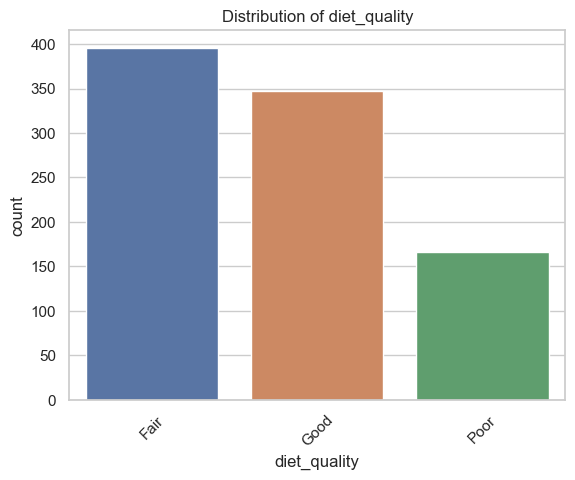

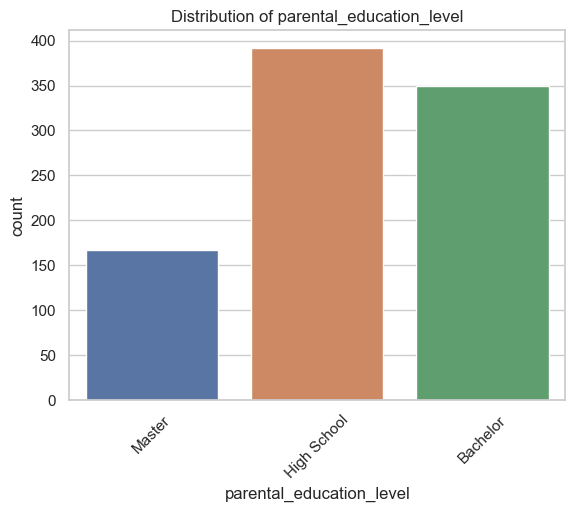

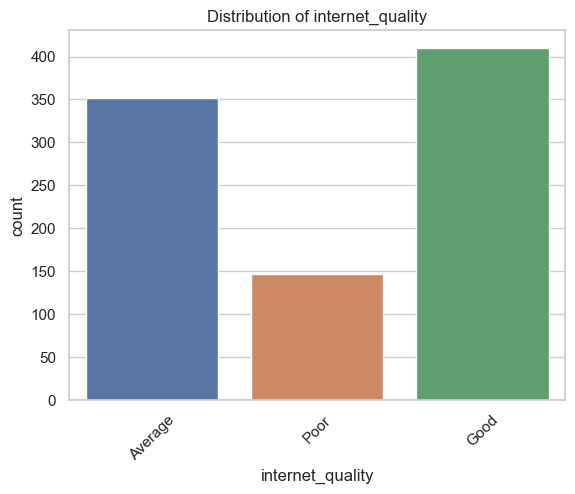

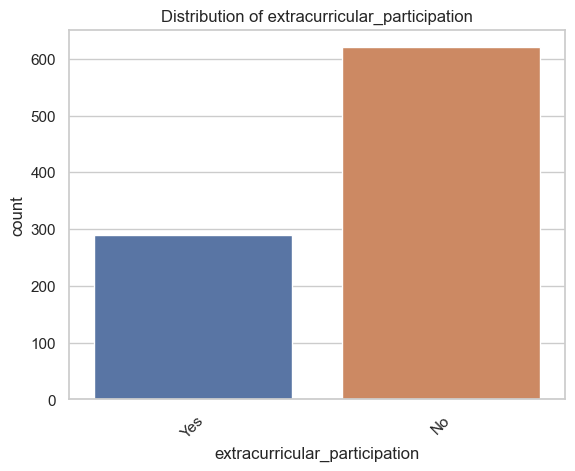

In [24]:
for col in categorical_cols:
    sns.countplot(data=df, x = col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation = 45)
    plt.show()

In [26]:
df.corr(numeric_only = True)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.007150,-0.023854,0.005841,-0.030203,0.040498,-0.005718,-0.052137,-0.012833
study_hours_per_day,0.007150,1.000000,0.007364,-0.014493,0.028967,-0.026241,-0.024708,-0.015896,0.822950
social_media_hours,-0.023854,0.007364,1.000000,0.011865,0.049356,0.026861,-0.023975,-0.000417,-0.171672
netflix_hours,0.005841,-0.014493,0.011865,1.000000,-0.015008,-0.017006,-0.004155,-0.016612,-0.166578
attendance_percentage,-0.030203,0.028967,0.049356,-0.015008,1.000000,0.001972,-0.010563,-0.017096,0.096005
sleep_hours,0.040498,-0.026241,0.026861,-0.017006,0.001972,1.000000,0.030013,-0.010653,0.122294
exercise_frequency,-0.005718,-0.024708,-0.023975,-0.004155,-0.010563,0.030013,1.000000,-0.001500,0.161397
mental_health_rating,-0.052137,-0.015896,-0.000417,-0.016612,-0.017096,-0.010653,-0.001500,1.000000,0.317945
exam_score,-0.012833,0.822950,-0.171672,-0.166578,0.096005,0.122294,0.161397,0.317945,1.000000


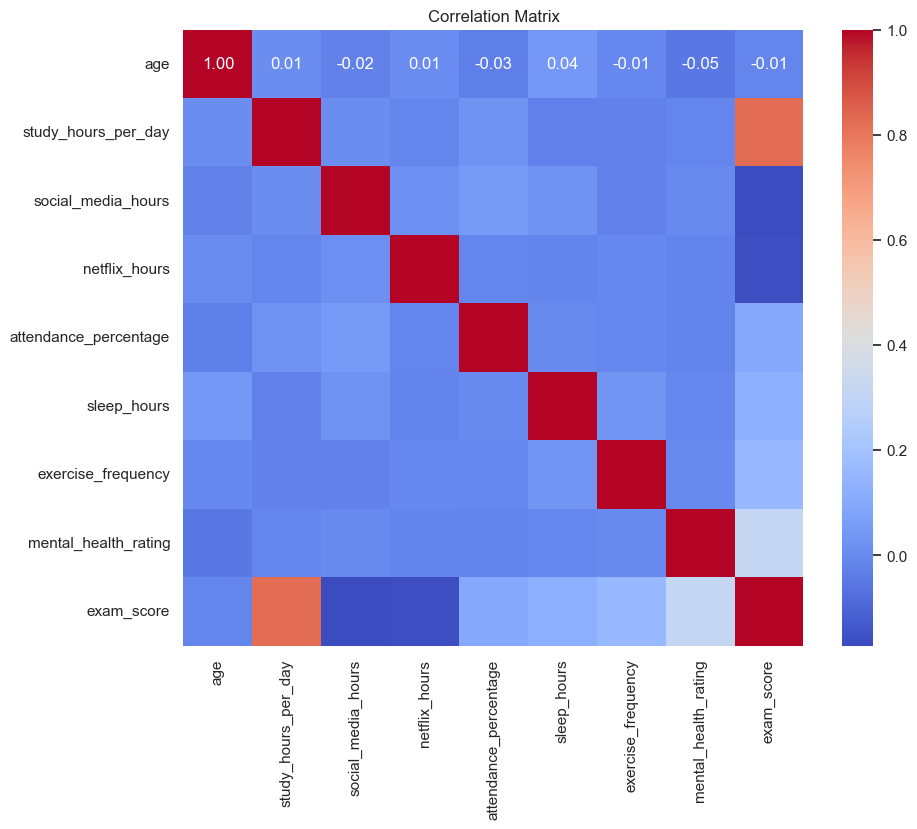

In [47]:
corr = df.corr(numeric_only = True).astype(float)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [42]:
corr = df.corr(numeric_only=True)
print(corr)

                            age  study_hours_per_day  social_media_hours  \
age                    1.000000             0.007150           -0.023854   
study_hours_per_day    0.007150             1.000000            0.007364   
social_media_hours    -0.023854             0.007364            1.000000   
netflix_hours          0.005841            -0.014493            0.011865   
attendance_percentage -0.030203             0.028967            0.049356   
sleep_hours            0.040498            -0.026241            0.026861   
exercise_frequency    -0.005718            -0.024708           -0.023975   
mental_health_rating  -0.052137            -0.015896           -0.000417   
exam_score            -0.012833             0.822950           -0.171672   

                       netflix_hours  attendance_percentage  sleep_hours  \
age                         0.005841              -0.030203     0.040498   
study_hours_per_day        -0.014493               0.028967    -0.026241   
social_medi

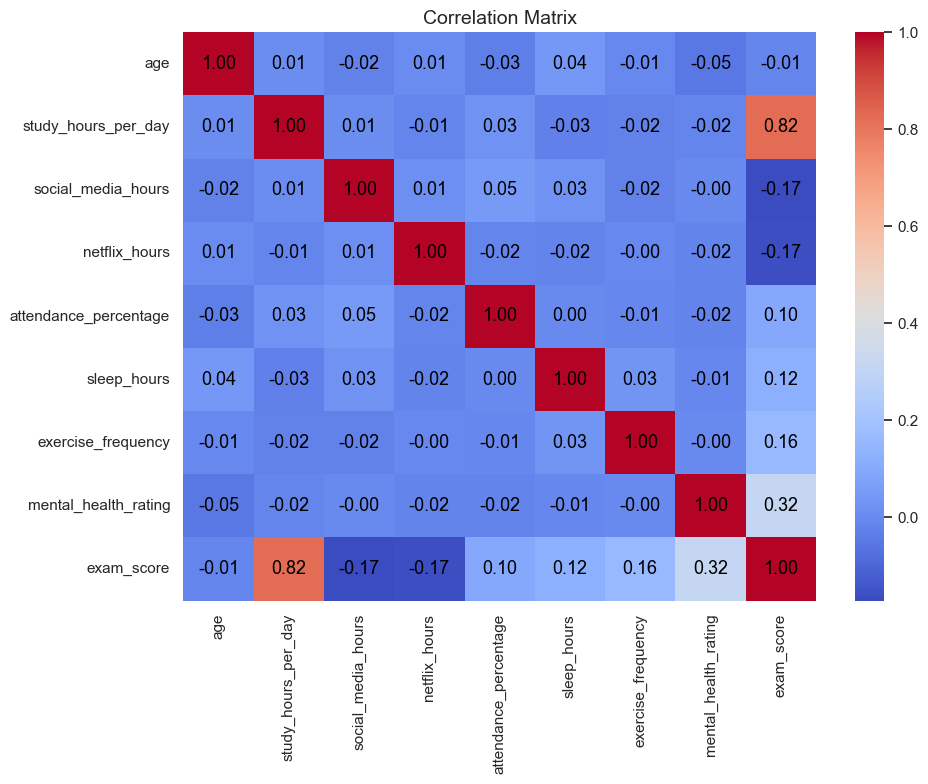

In [48]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', cbar=True, ax=ax)

# Manually add the annotations
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        text = f"{corr.iloc[i, j]:.2f}"
        ax.text(j+0.5, i+0.5, text,
                ha='center', va='center', color='black', fontsize=13)

ax.set_title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [50]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [51]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

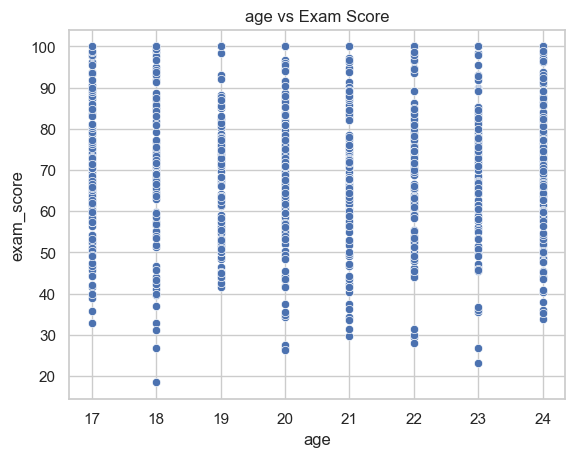

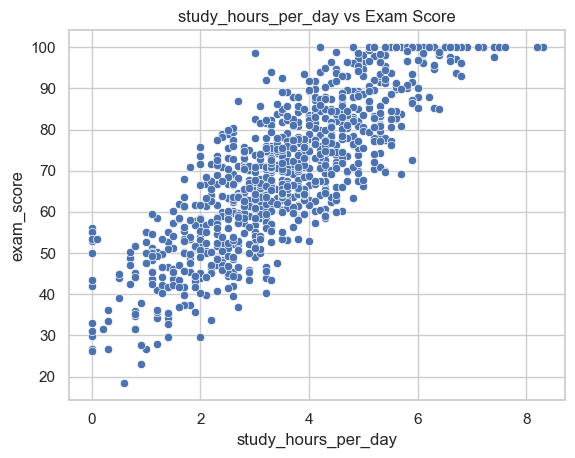

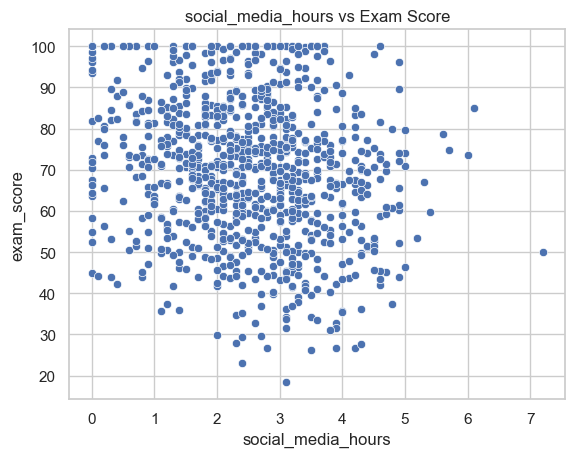

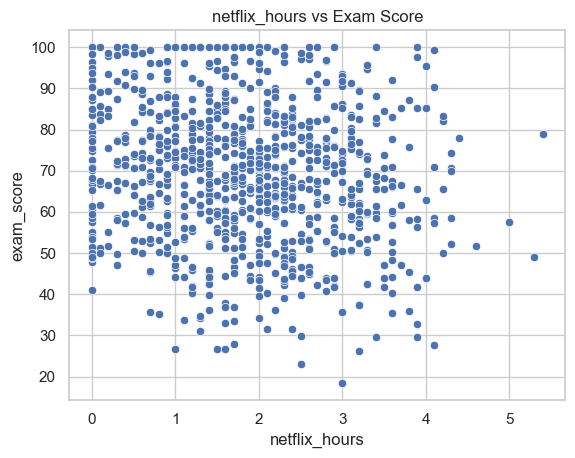

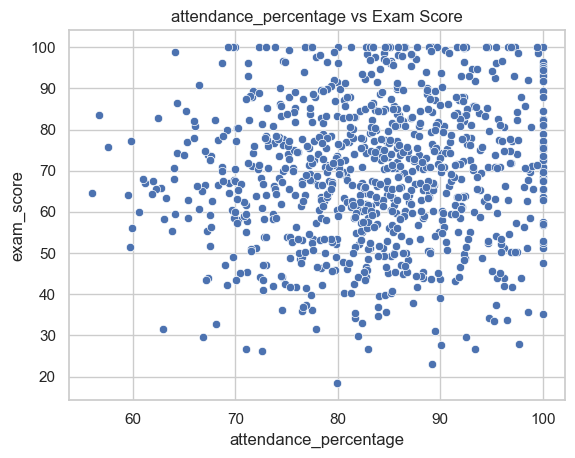

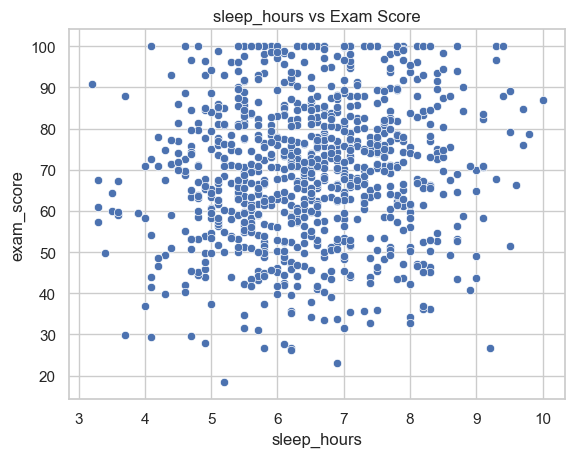

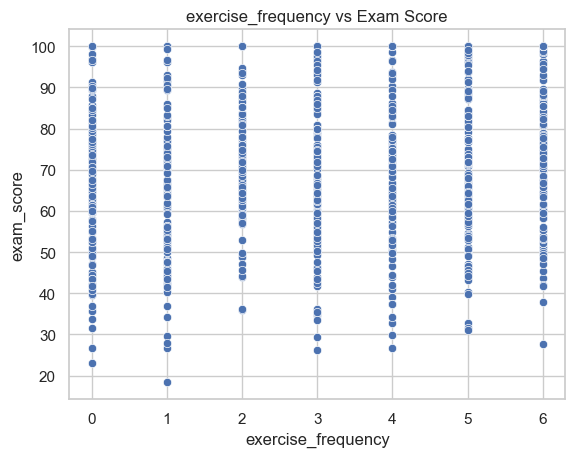

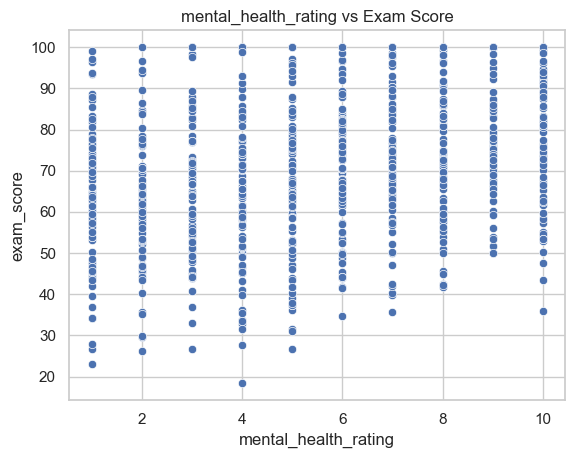

In [56]:
for feature in num_features:
    sns.scatterplot(data = df , x = feature, y = "exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()

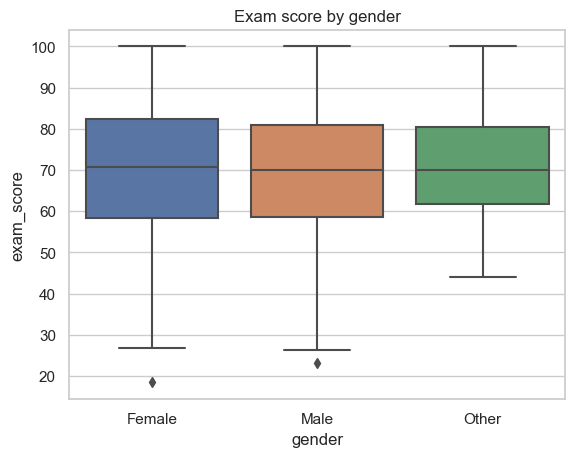

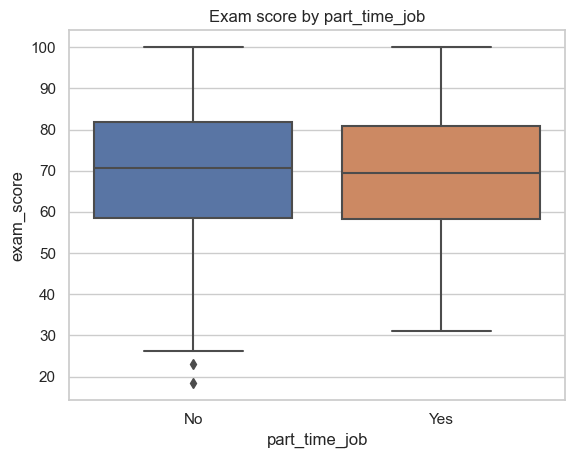

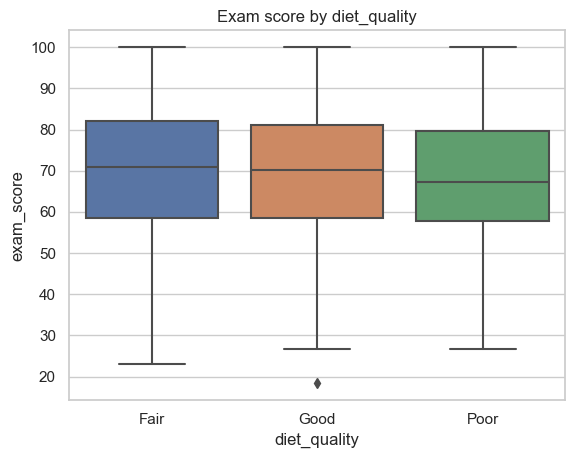

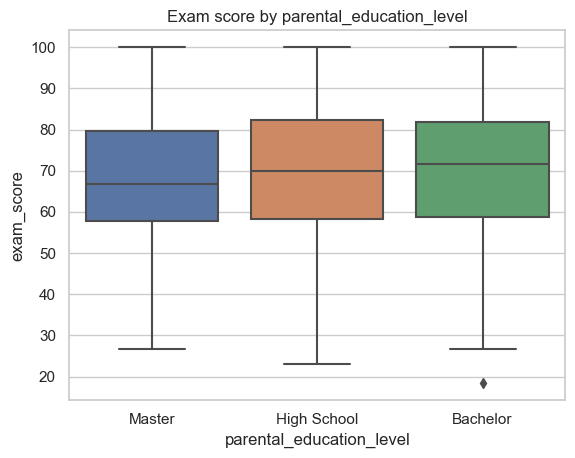

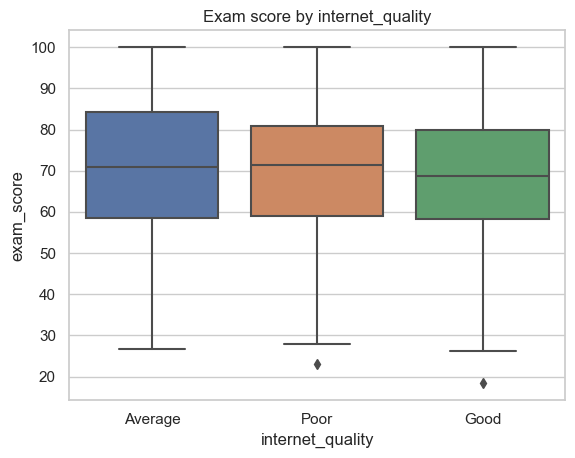

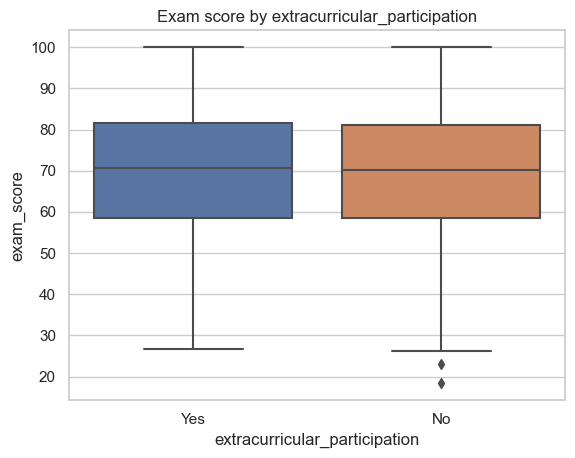

In [59]:
for col in categorical_cols:
    sns.boxplot(data=df,x=col,y="exam_score")
    plt.title(f"Exam score by {col}")
    plt.show()

In [60]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [61]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [62]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [63]:
features = ['study_hours_per_day','attendance_percentage','mental_health_rating','sleep_hours','part_time_job']

In [64]:
target = "exam_score"

In [65]:
df_model = df[features + [target]].copy()

In [66]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [67]:
le = LabelEncoder()

In [68]:
df_model['part_time_job'] = le.fit_transform(df_model['part_time_job'])

In [69]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [70]:
x = df_model[features]

In [71]:
y = df_model[target]

In [72]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [73]:
len(y_test)

182

In [74]:
len(y_train)

727

In [77]:
models = {
    'LinearRegression':{
        'model': LinearRegression(),
        'params':{}
    },
    'DecisionTree':{
        'model': DecisionTreeRegressor(),
        'params': {'max_depth': [3,5,10],'min_samples_split':[2,5]}
    },
    'RandomForest':{
        'model': RandomForestRegressor(),
        'params': {'n_estimators':[50,100],'max_depth':[5,10]}
    }
    
}

In [76]:
best_models = []

In [79]:
for name, config in models.items():
    print(f"Training{name}")
    
    grid = GridSearchCV(config['model'],config['params'],cv = 5, scoring='neg_mean_squared_error')
    grid.fit(x_train, y_train)
    
    y_pred = grid.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    best_models.append({
        'model': name,
        'best_params': grid.best_params_,
        'rmse' : rmse,
        'r2' :r2
    })

TrainingLinearRegression
TrainingDecisionTree
TrainingRandomForest


In [80]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': 7.3948634618609255,
  'r2': 0.8220273039598782},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': 8.616128394558485,
  'r2': 0.7583886208950241},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 5, 'n_estimators': 100},
  'rmse': 7.749310989554439,
  'r2': 0.8045573960596345}]

In [81]:
result_df = pd.DataFrame(best_models)

In [83]:
result_df.sort_values(by='rmse')

,model,best_params,rmse,r2
0,LinearRegression,{},7.394863,0.822027
2,RandomForest,"{'max_depth': 5, 'n_estimators': 100}",7.749311,0.804557
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.616128,0.758389


In [86]:
import joblib

best_row = result_df.sort_values(by='rmse').iloc[0]

In [87]:
best_row

model          LinearRegression
best_params                  {}
rmse                   7.394863
r2                     0.822027
Name: 0, dtype: object

In [88]:
best_model_name = best_row['model']

In [89]:
best_model_name

'LinearRegression'

In [90]:
best_model_config = models[best_model_name]

In [91]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [92]:
final_model = best_model_config['model']

In [93]:
final_model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
final_model.predict(x_test)

array([ 40.74930647,  81.14151653,  80.70978686,  45.83696497,
        67.76353877,  61.46176878,  87.18702105,  65.9872718 ,
        63.52287934,  57.96780871,  63.46863323,  64.51168013,
        56.76860088,  70.52056298,  83.02517528,  65.10743322,
        64.05479374,  72.45303949,  60.70117069,  73.35099897,
        63.44842876,  57.77560058,  79.7245903 ,  89.38708519,
        85.23484959,  71.89251839,  49.74310692,  50.37910151,
        70.24515583,  57.45595147,  75.00352966,  53.68824906,
        82.16654734,  91.82549796,  60.08723101,  62.79878985,
        63.42570115,  78.07562614,  69.13935515,  59.41323383,
        33.01259124,  55.14195272,  71.06624832,  81.34776381,
        73.17116424,  63.60625277,  71.10976502,  37.5268067 ,
        71.16917324,  40.85472813,  62.15277743,  72.24230521,
        72.47549093,  86.71282094,  79.39421509,  85.2652158 ,
        60.18318046,  68.64068393,  37.03563612,  61.60372745,
        95.41329797,  42.12695617,  60.92025364,  65.24

In [95]:
joblib.dump(final_model,'best_model.pkl')

['best_model.pkl']

In [96]:
joblib.load("best_model.pkl").predict(x_test)

array([ 40.74930647,  81.14151653,  80.70978686,  45.83696497,
        67.76353877,  61.46176878,  87.18702105,  65.9872718 ,
        63.52287934,  57.96780871,  63.46863323,  64.51168013,
        56.76860088,  70.52056298,  83.02517528,  65.10743322,
        64.05479374,  72.45303949,  60.70117069,  73.35099897,
        63.44842876,  57.77560058,  79.7245903 ,  89.38708519,
        85.23484959,  71.89251839,  49.74310692,  50.37910151,
        70.24515583,  57.45595147,  75.00352966,  53.68824906,
        82.16654734,  91.82549796,  60.08723101,  62.79878985,
        63.42570115,  78.07562614,  69.13935515,  59.41323383,
        33.01259124,  55.14195272,  71.06624832,  81.34776381,
        73.17116424,  63.60625277,  71.10976502,  37.5268067 ,
        71.16917324,  40.85472813,  62.15277743,  72.24230521,
        72.47549093,  86.71282094,  79.39421509,  85.2652158 ,
        60.18318046,  68.64068393,  37.03563612,  61.60372745,
        95.41329797,  42.12695617,  60.92025364,  65.24